# Supplementary Figures S31–S38: zebrafish downstream panels

These cells read the included numerical results, calculate the panel summaries, and draw new figures.

## Run the notebook

This page starts with the paper's saved inputs. Run its Python cells from top to bottom to create the output shown here.

To start from the trained model, follow [populations, growth and gene dynamics](zebrafish_model_figures.md) and [daughter-cell perturbations](zebrafish_daughter_noise.md). Those tutorials calculate new results and draw the corresponding paper figures. The [analysis and input guide](../../reference/figure_sources/zebrafish-si.md) includes the loss-weight comparison.

## Load figure inputs


In [1]:
import os
import pandas as pd

pd.set_option("display.max_colwidth", None)
pd.set_option("display.max_columns", None)

from pathlib import Path

from IPython.display import Image, display

from CytoBridge.results import (
    calculate_zebrafish_si_panels,
    load_zebrafish_si_results,
    plot_zebrafish_si,
    write_zebrafish_si_tables,
)

output_dir = Path(os.environ.get("CYTOBRIDGE_PROJECT_DIR", ".")) / "outputs" / "zebrafish_si_s31_s38"
output_dir.mkdir(parents=True, exist_ok=True)
results = load_zebrafish_si_results()
{
    "s31_frames": results.observed_generated.n_frames,
    "s33_frames": results.virtual_removal.n_frames,
    "growth_rows": len(results.growth),
}


{'s31_frames': 14, 's33_frames': 15, 'growth_rows': 11999}

## Recalculate panel values


In [2]:
panels = calculate_zebrafish_si_panels(results)
tables = write_zebrafish_si_tables(panels, output_dir)
{name: path.name for name, path in tables.items()}


{'growth_quantiles': 'growth_quantiles.csv',
 'ablation_centroid': 'ablation_centroid.csv',
 'gene_zscores': 'gene_zscores.csv',
 'loss_weight': 'loss_weight.csv',
 'daughter_composition': 'daughter_composition.csv',
 'daughter_lineage': 'daughter_lineage.csv',
 'daughter_sensitivity': 'daughter_sensitivity.csv',
 'daughter_particles': 'daughter_particles.csv',
 'inverse_pca': 'inverse_pca.csv'}

## Draw and save the figure


In [3]:
figures = plot_zebrafish_si(results, output_dir, panels)
{name: [path.name for path in paths] for name, paths in figures.items()}

from reproduction.paper_figures import draw_supplementary
figures.update(draw_supplementary([34, 36], output_dir))

## Preview the generated figures

The preceding plotting call created these PNG files during this notebook run.

S31


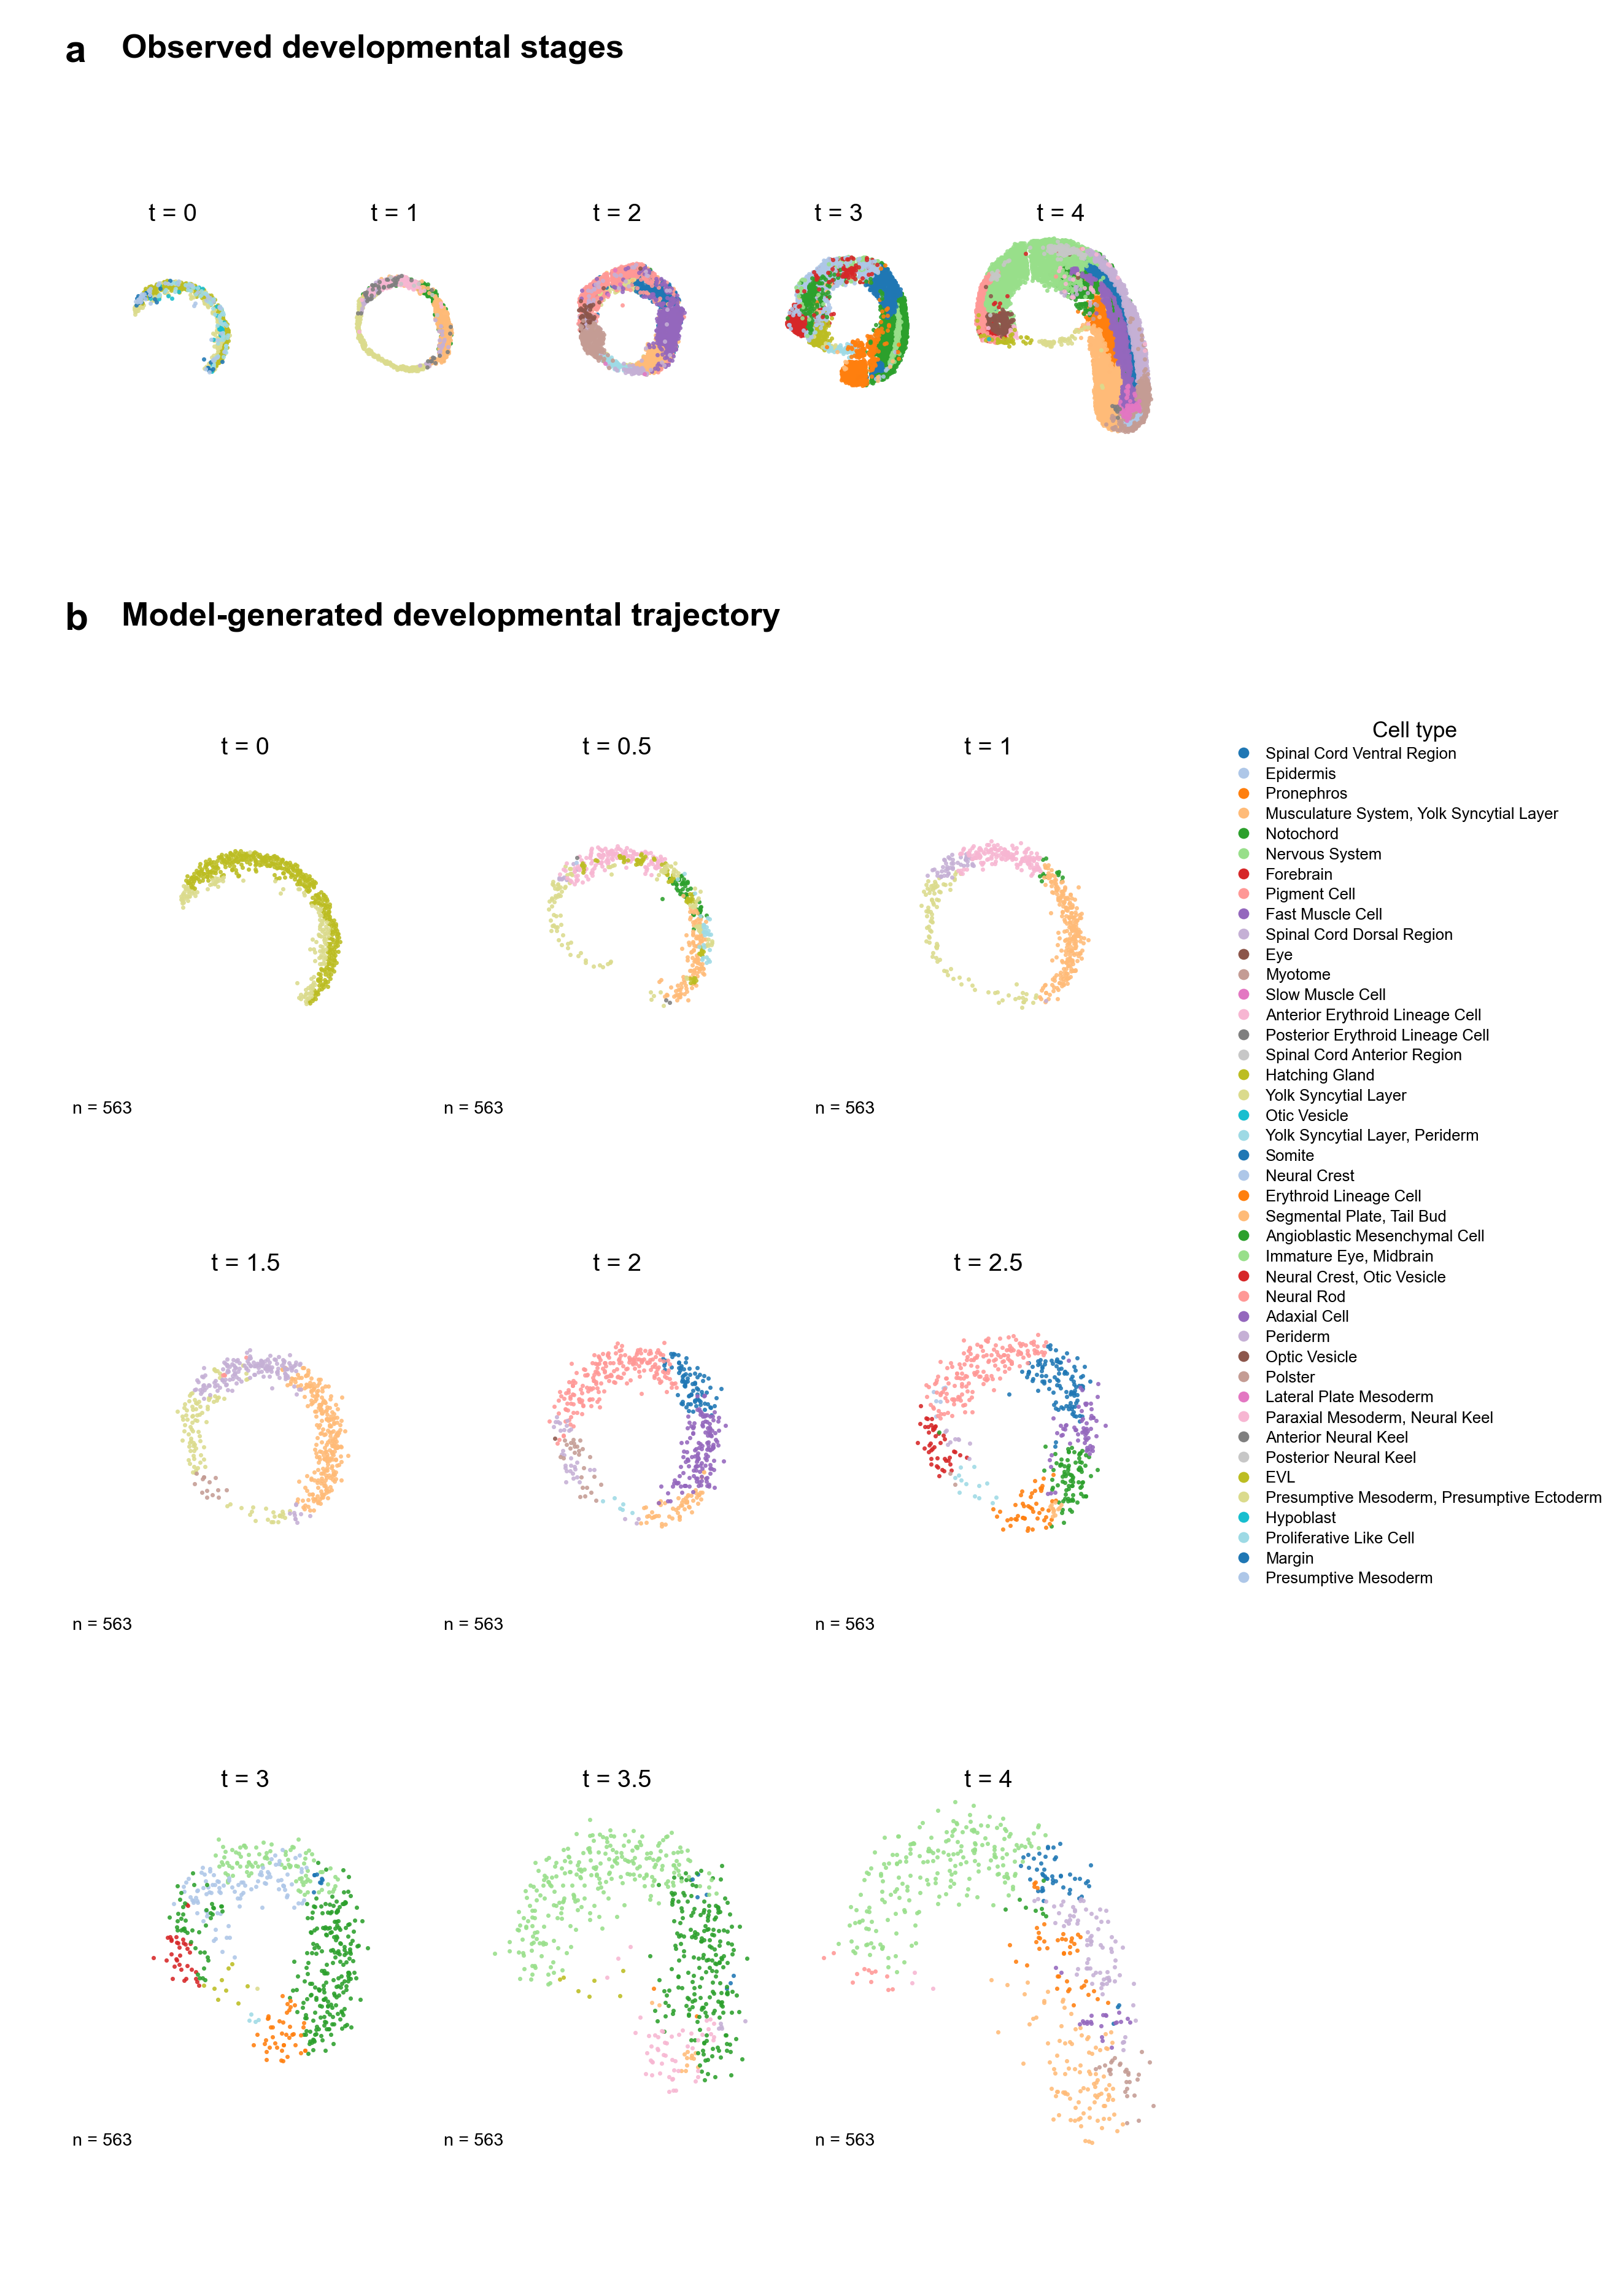

S32


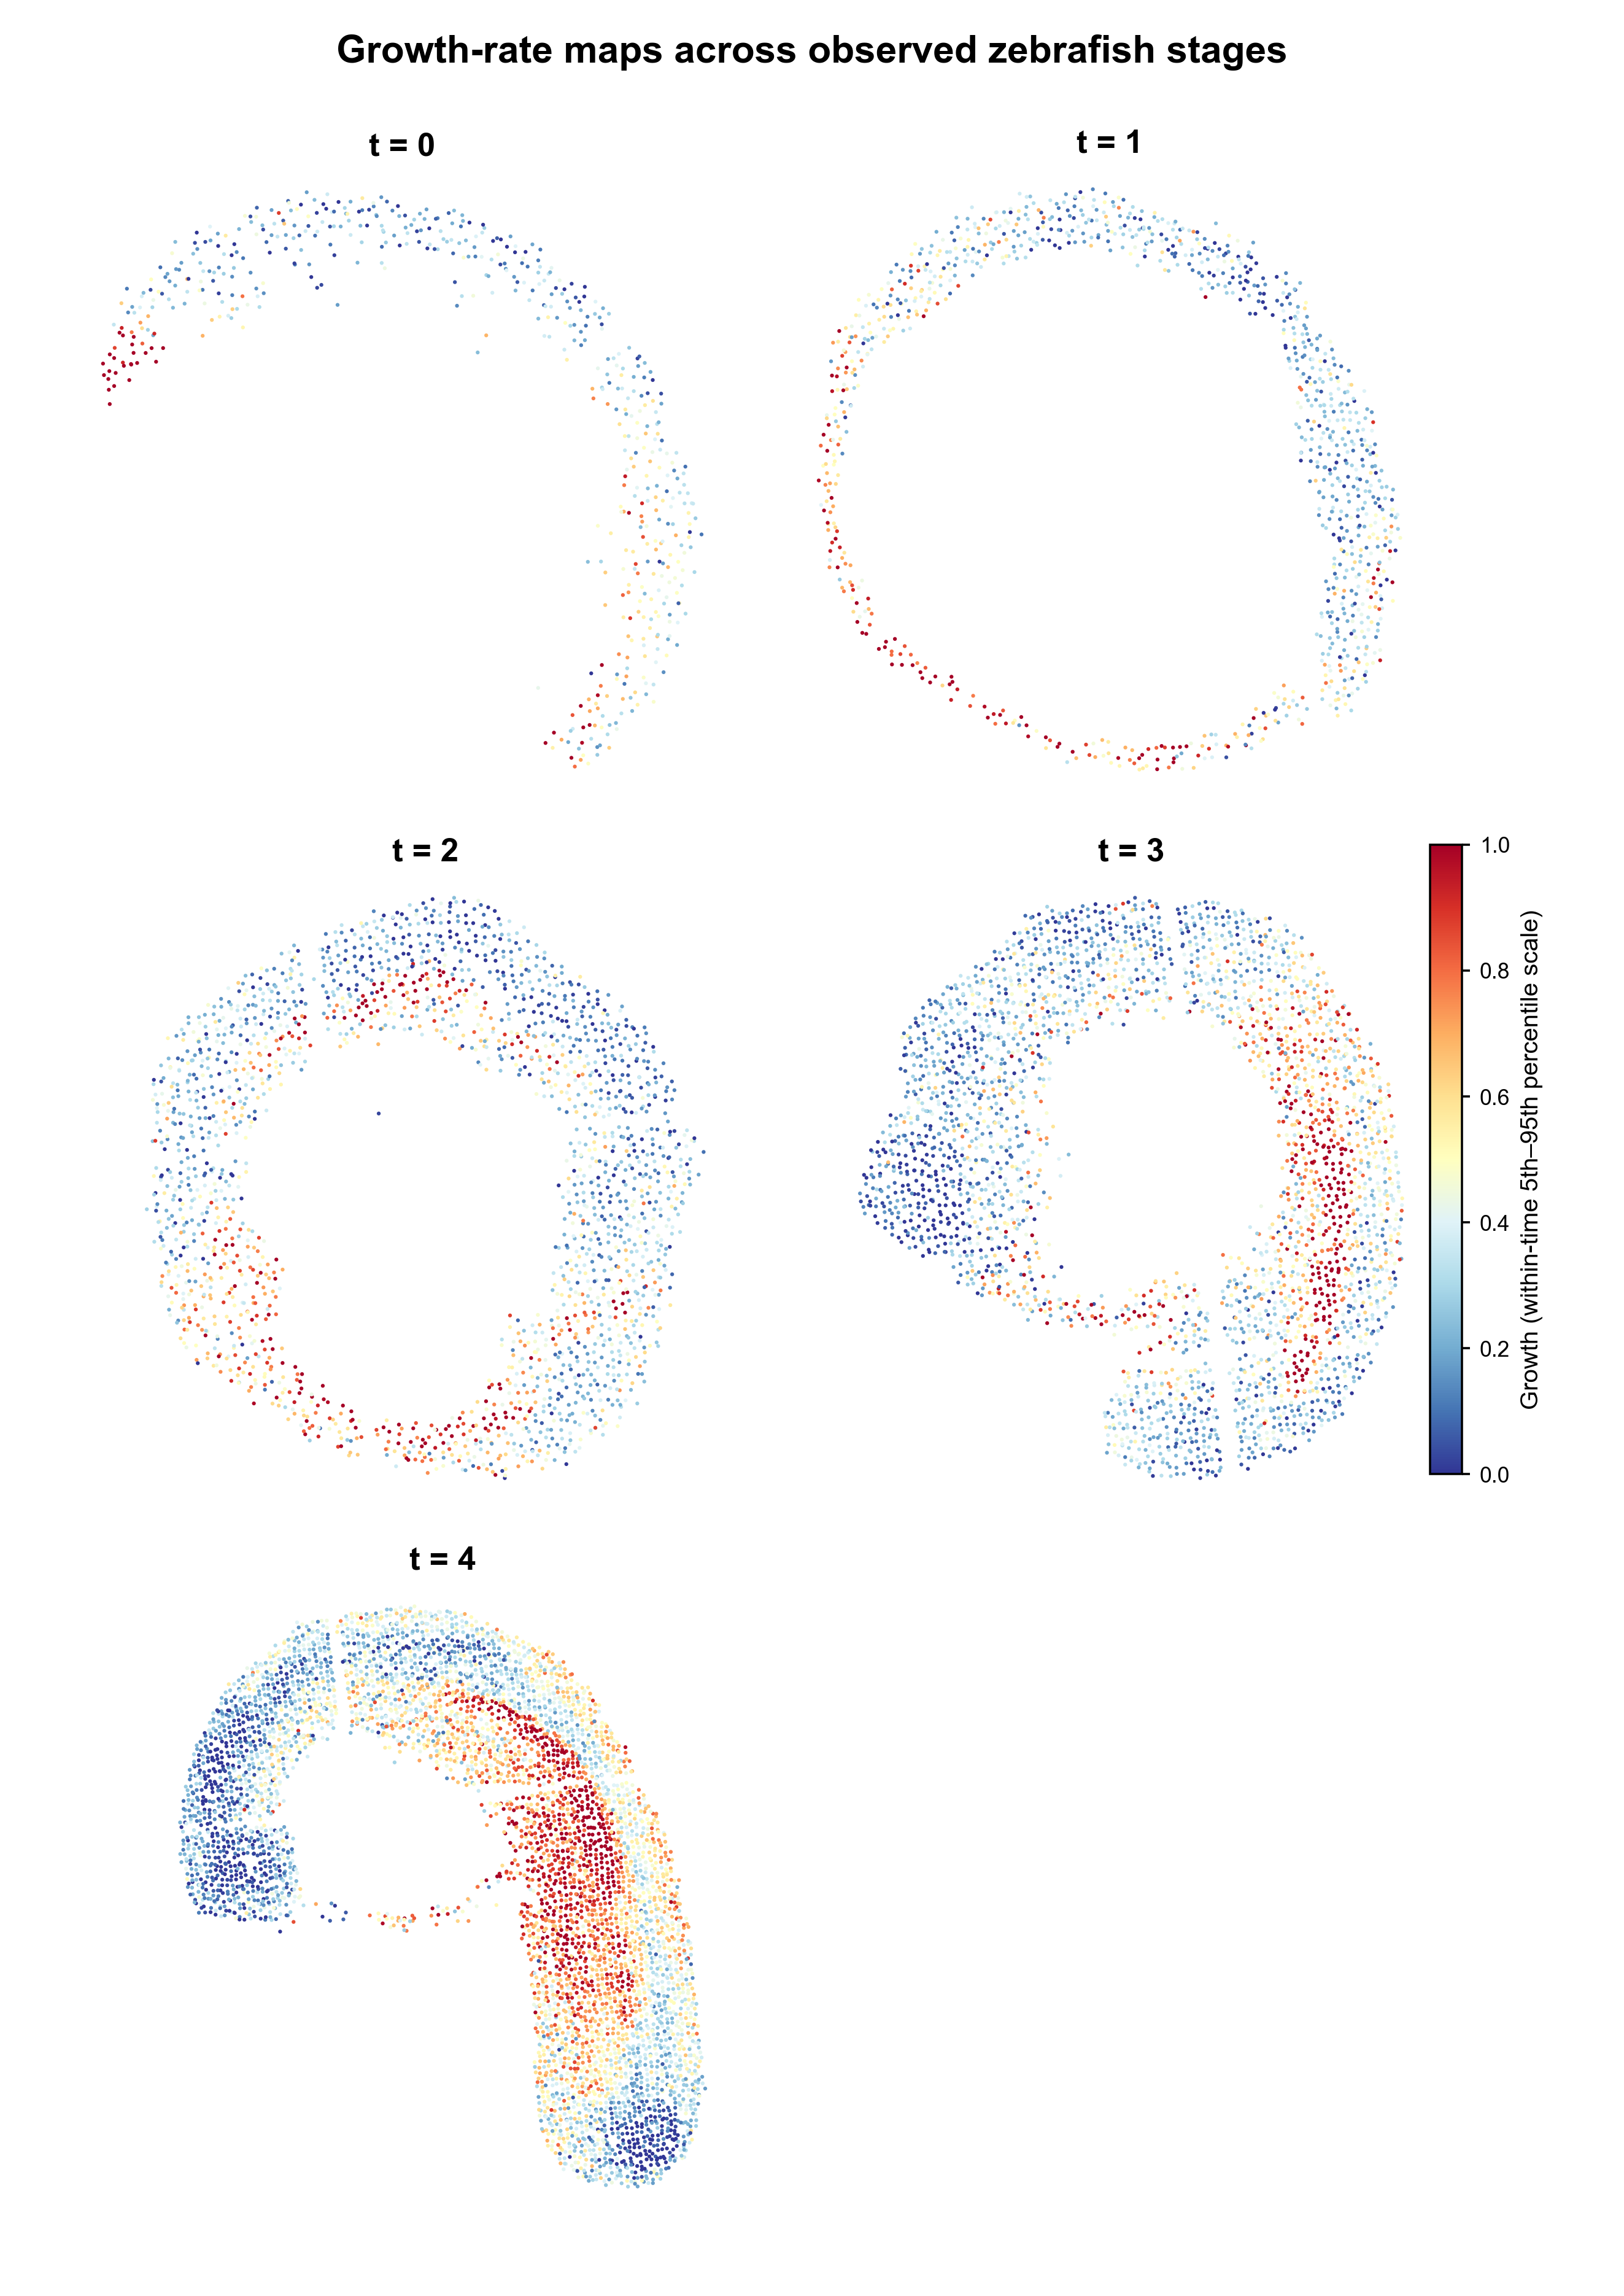

S33


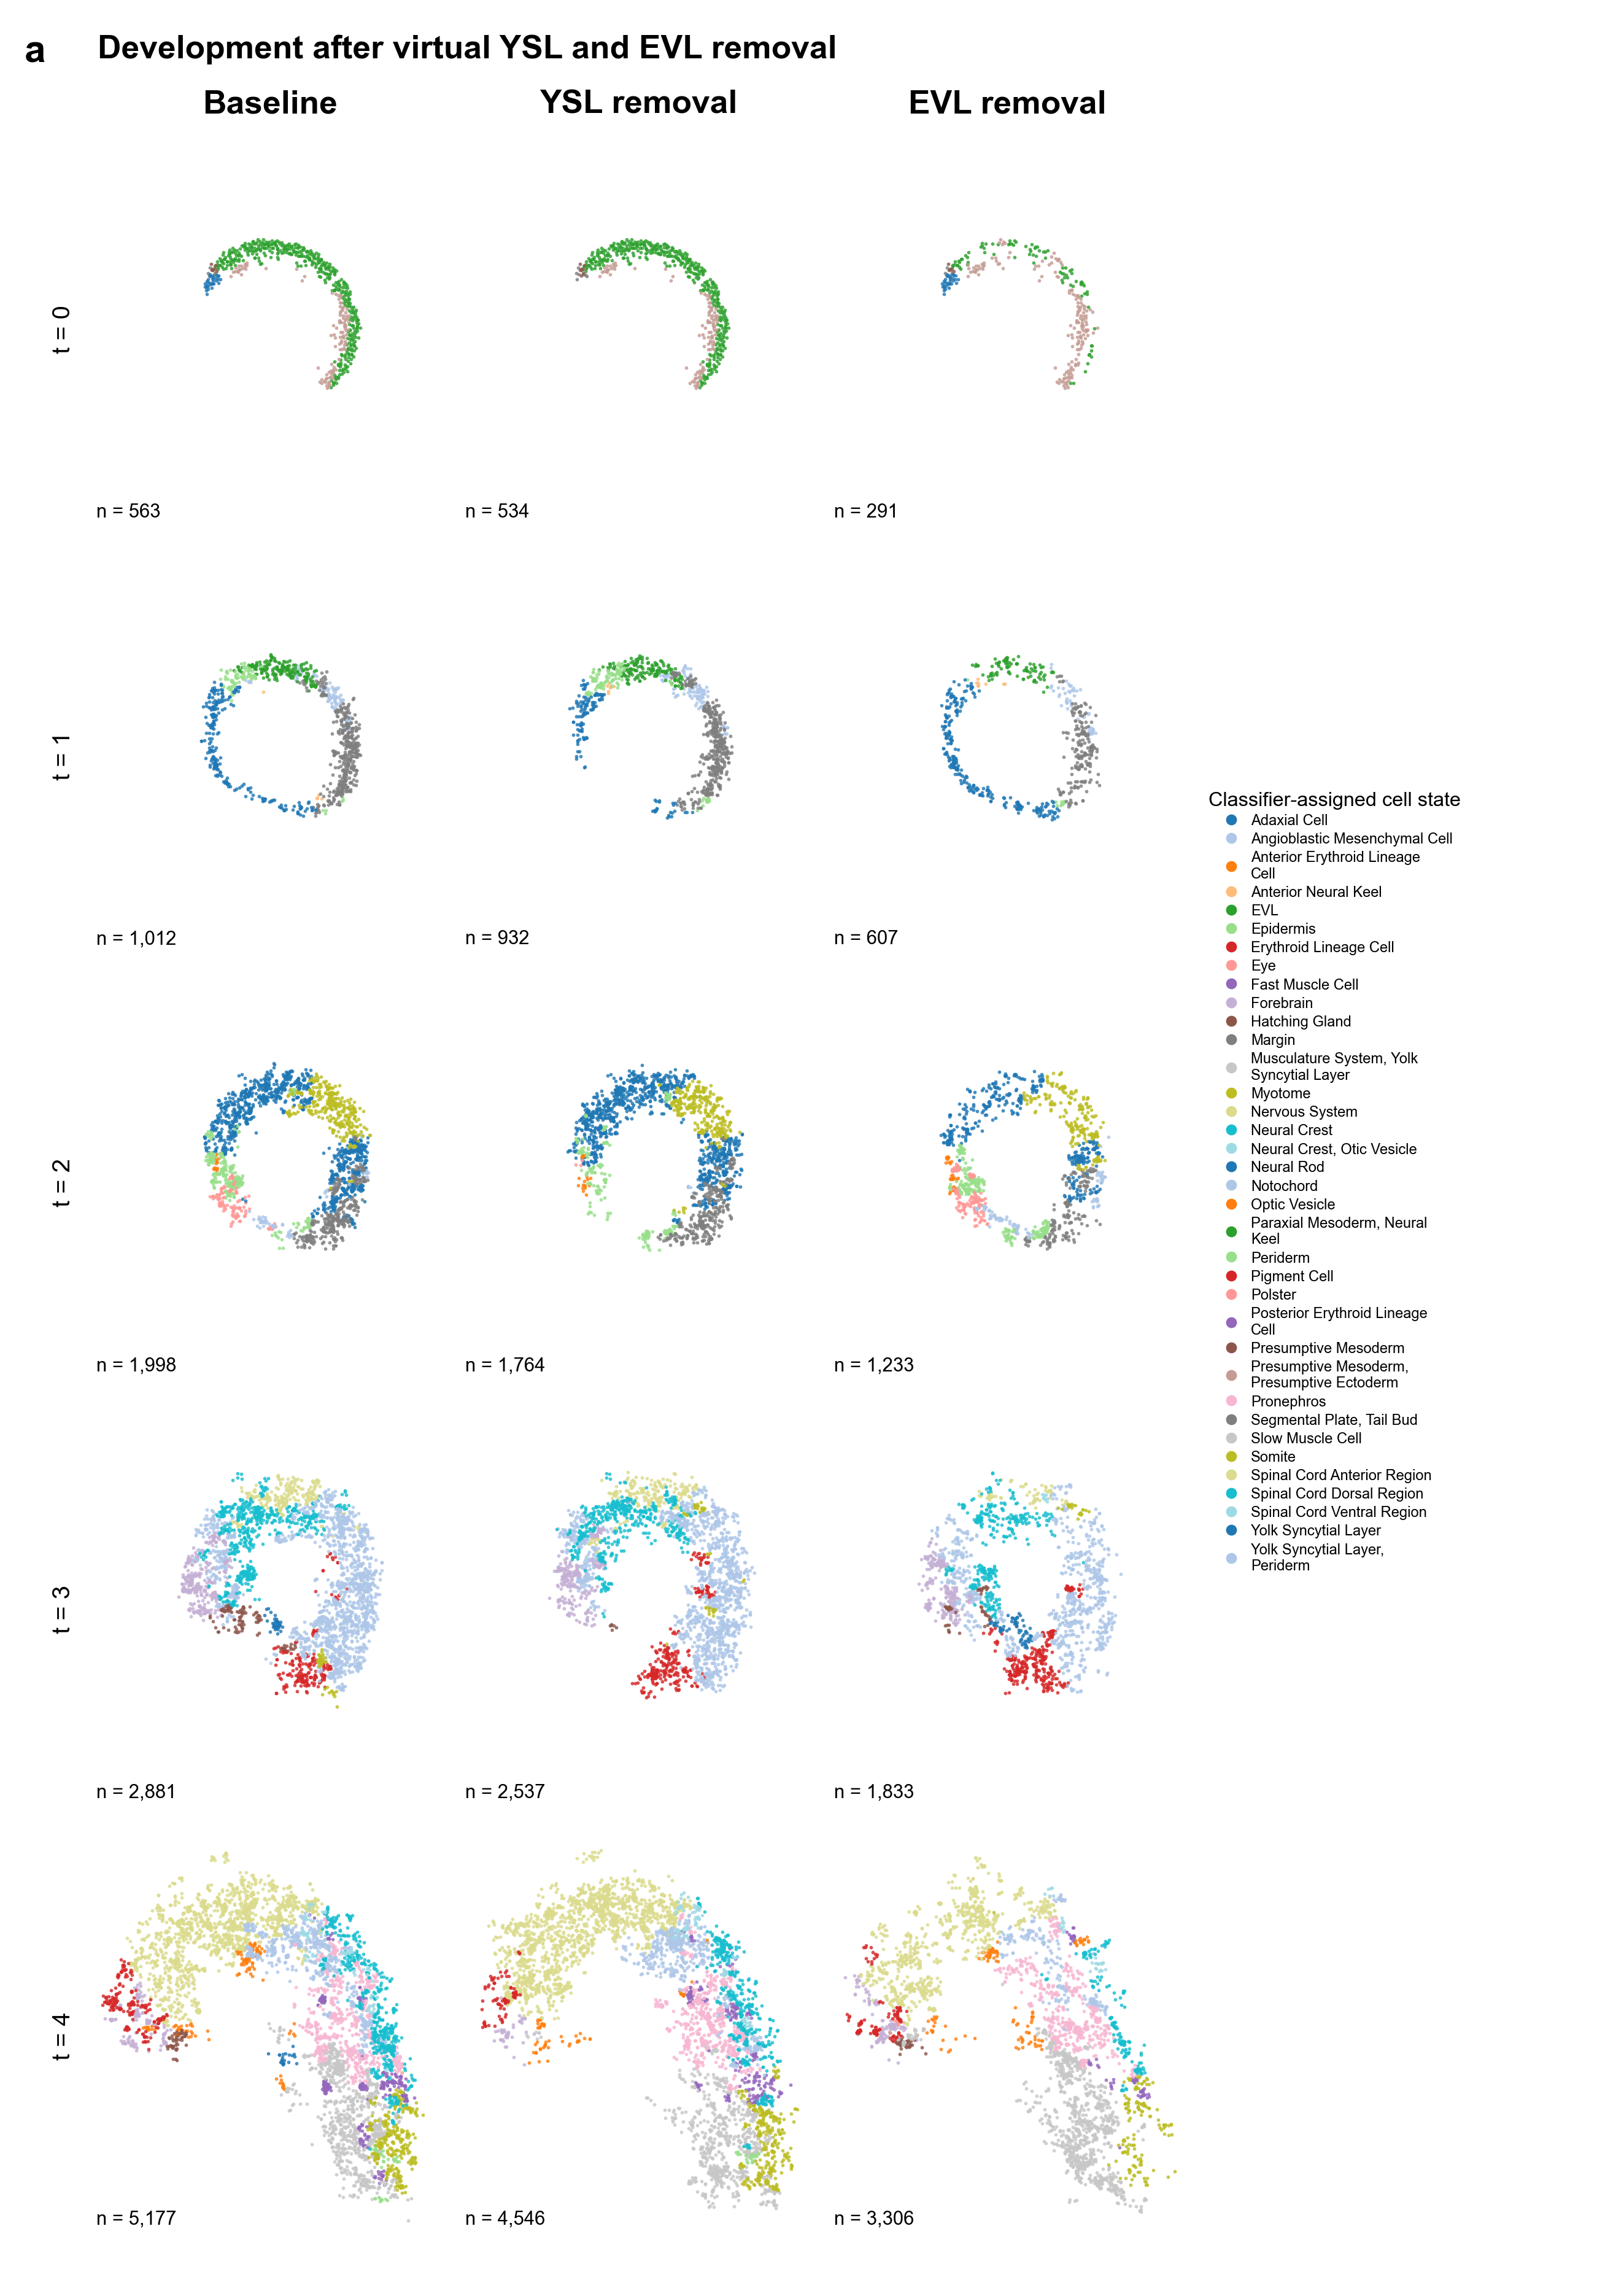

S34


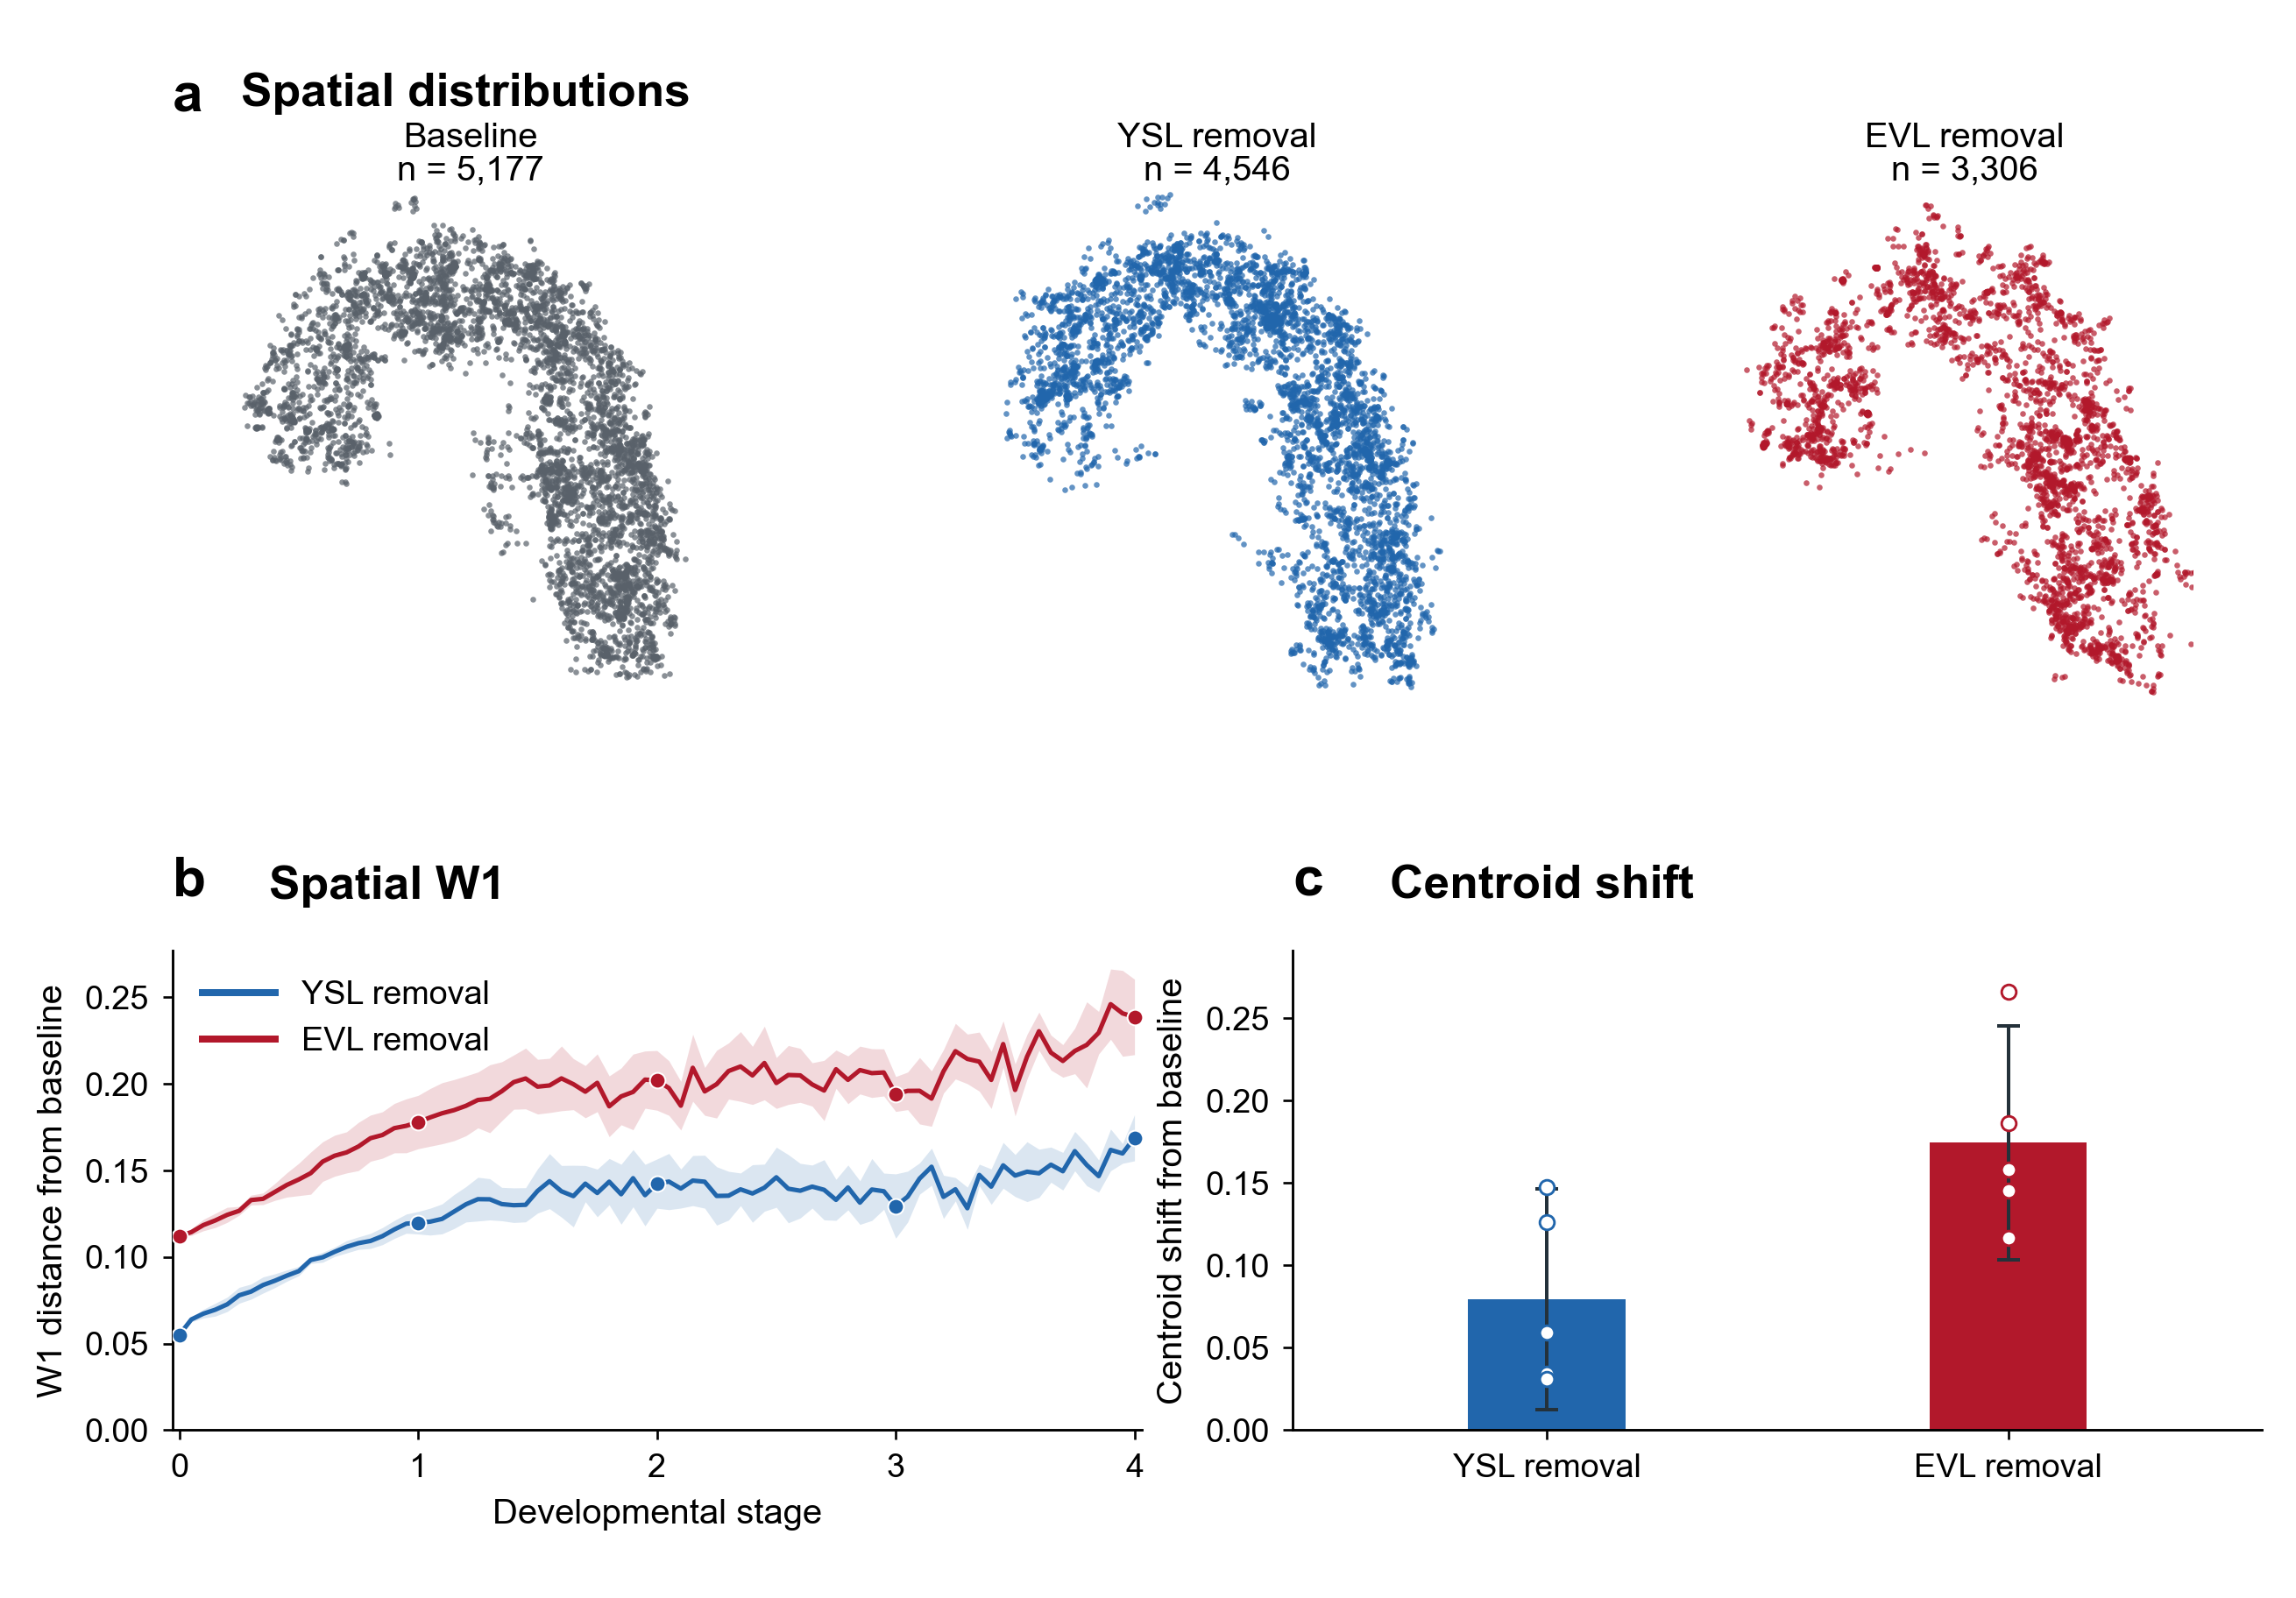

S35


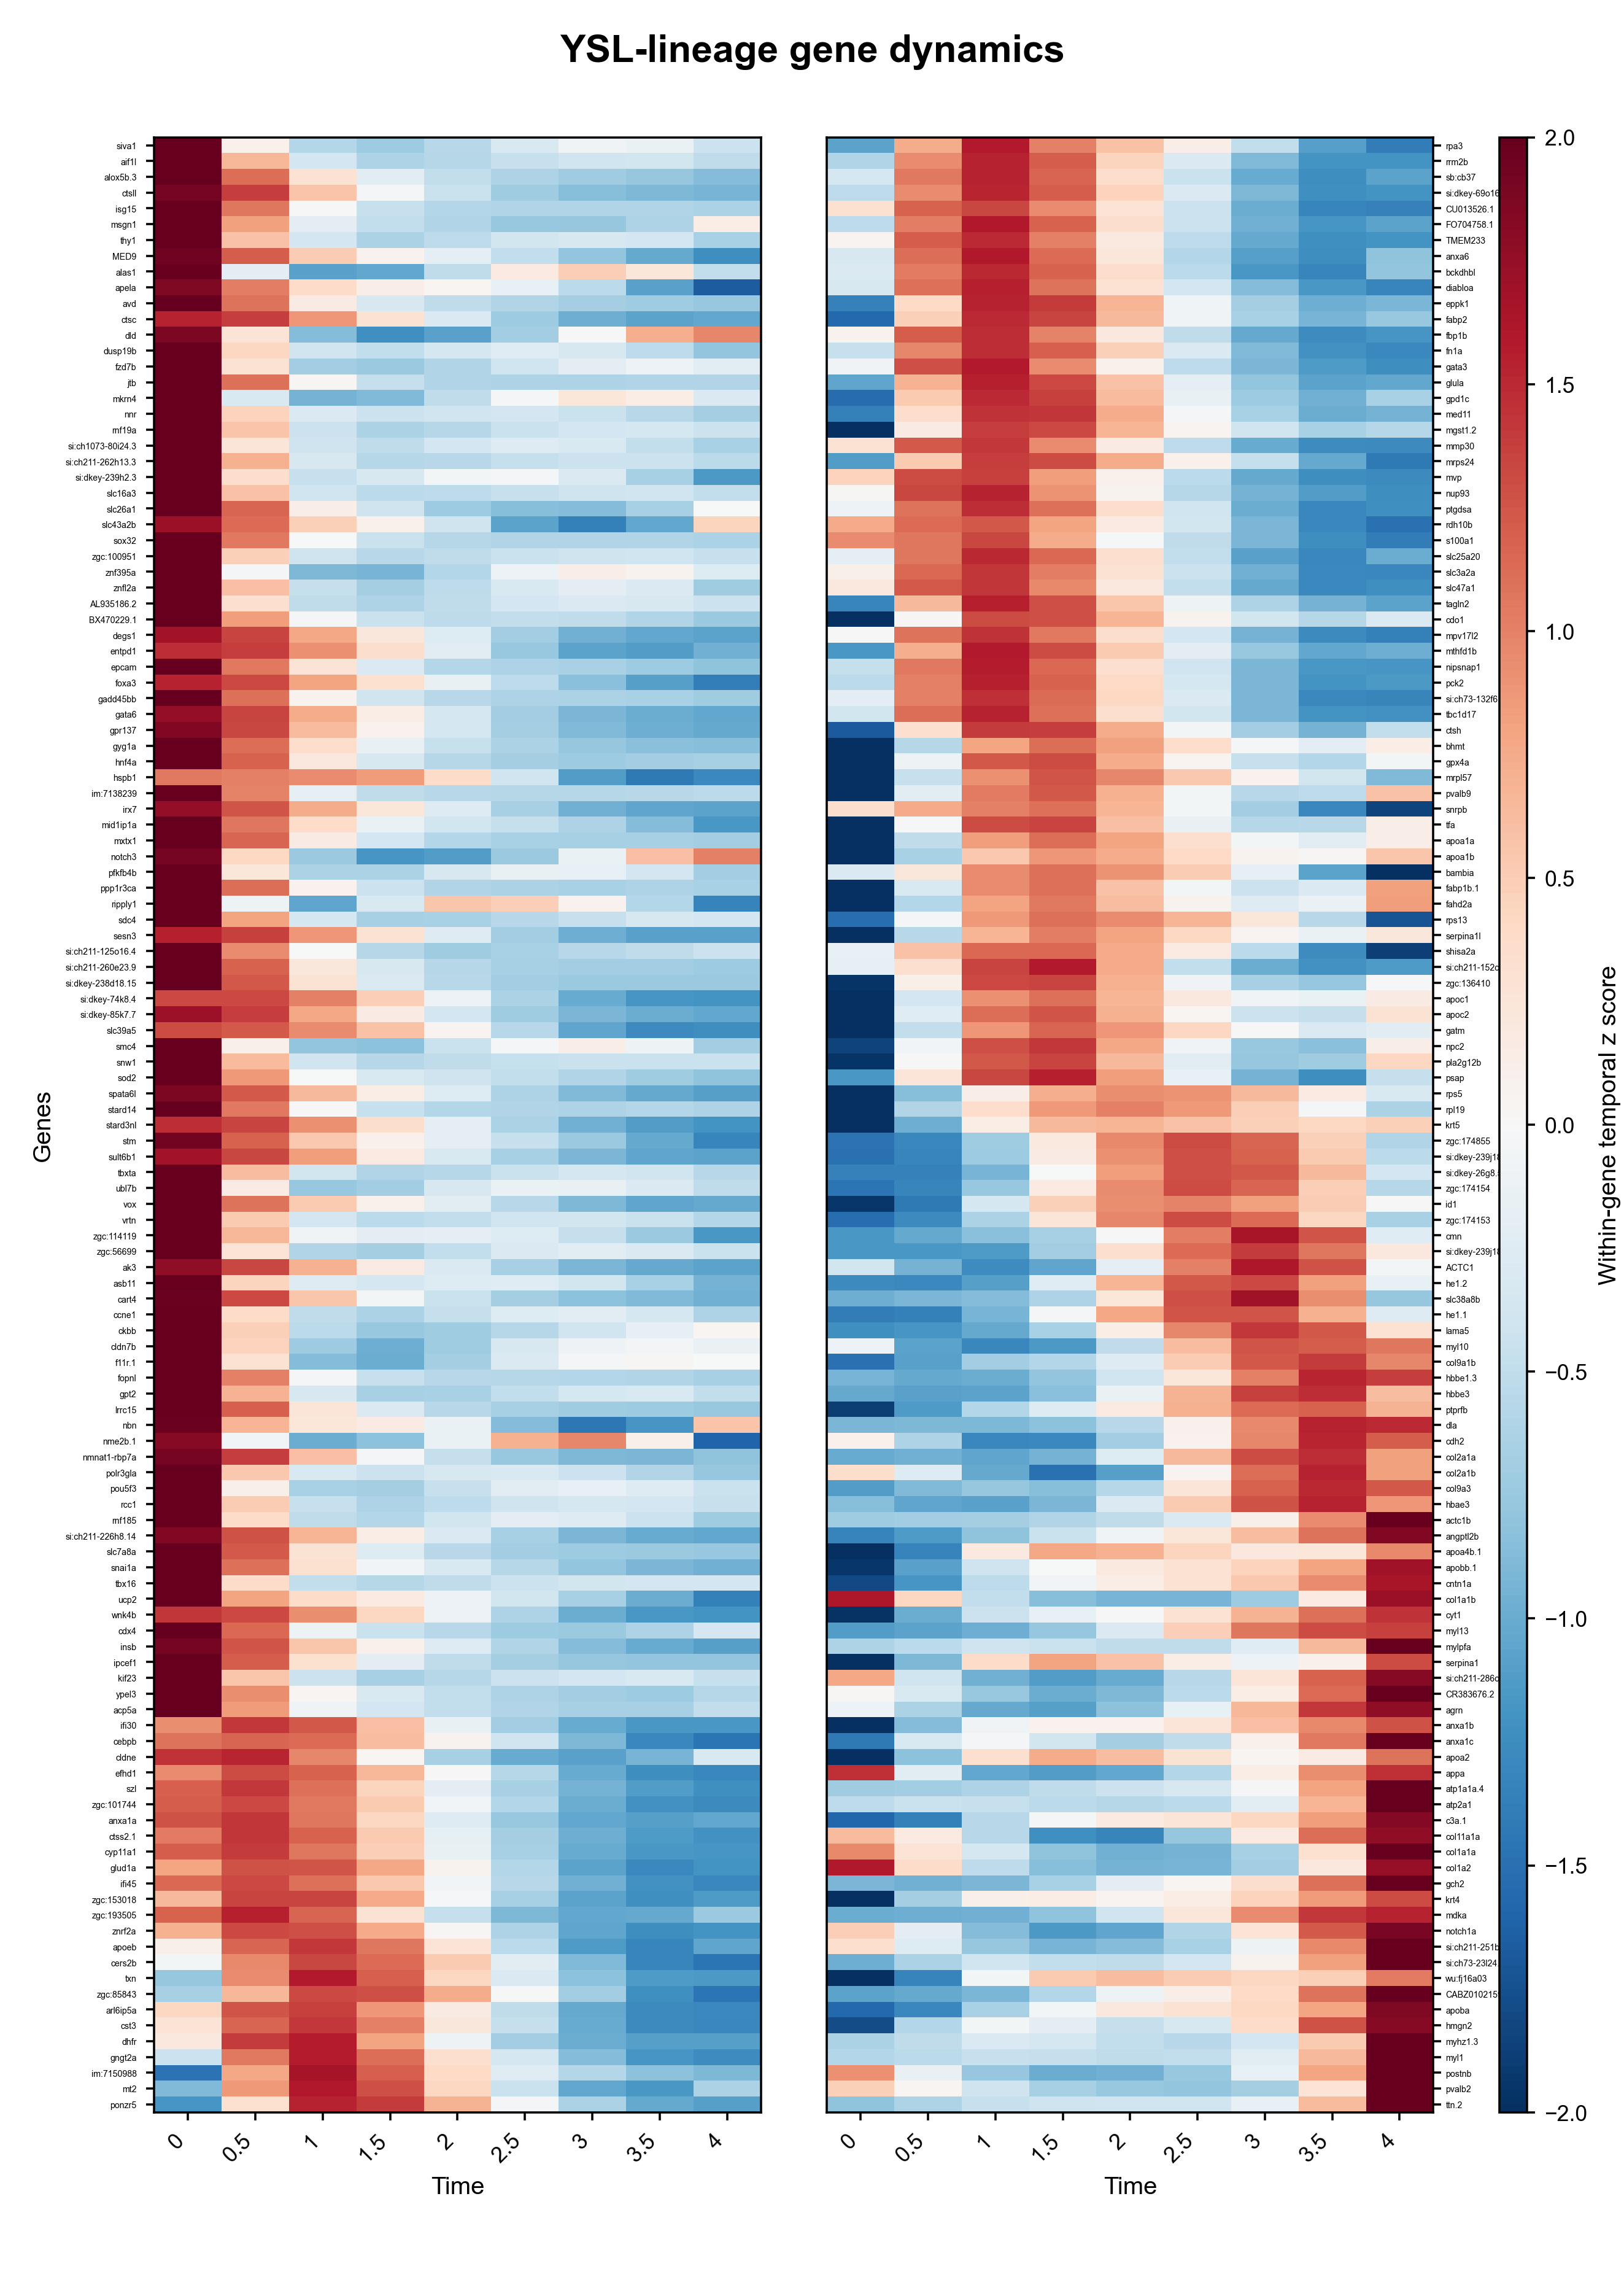

S36


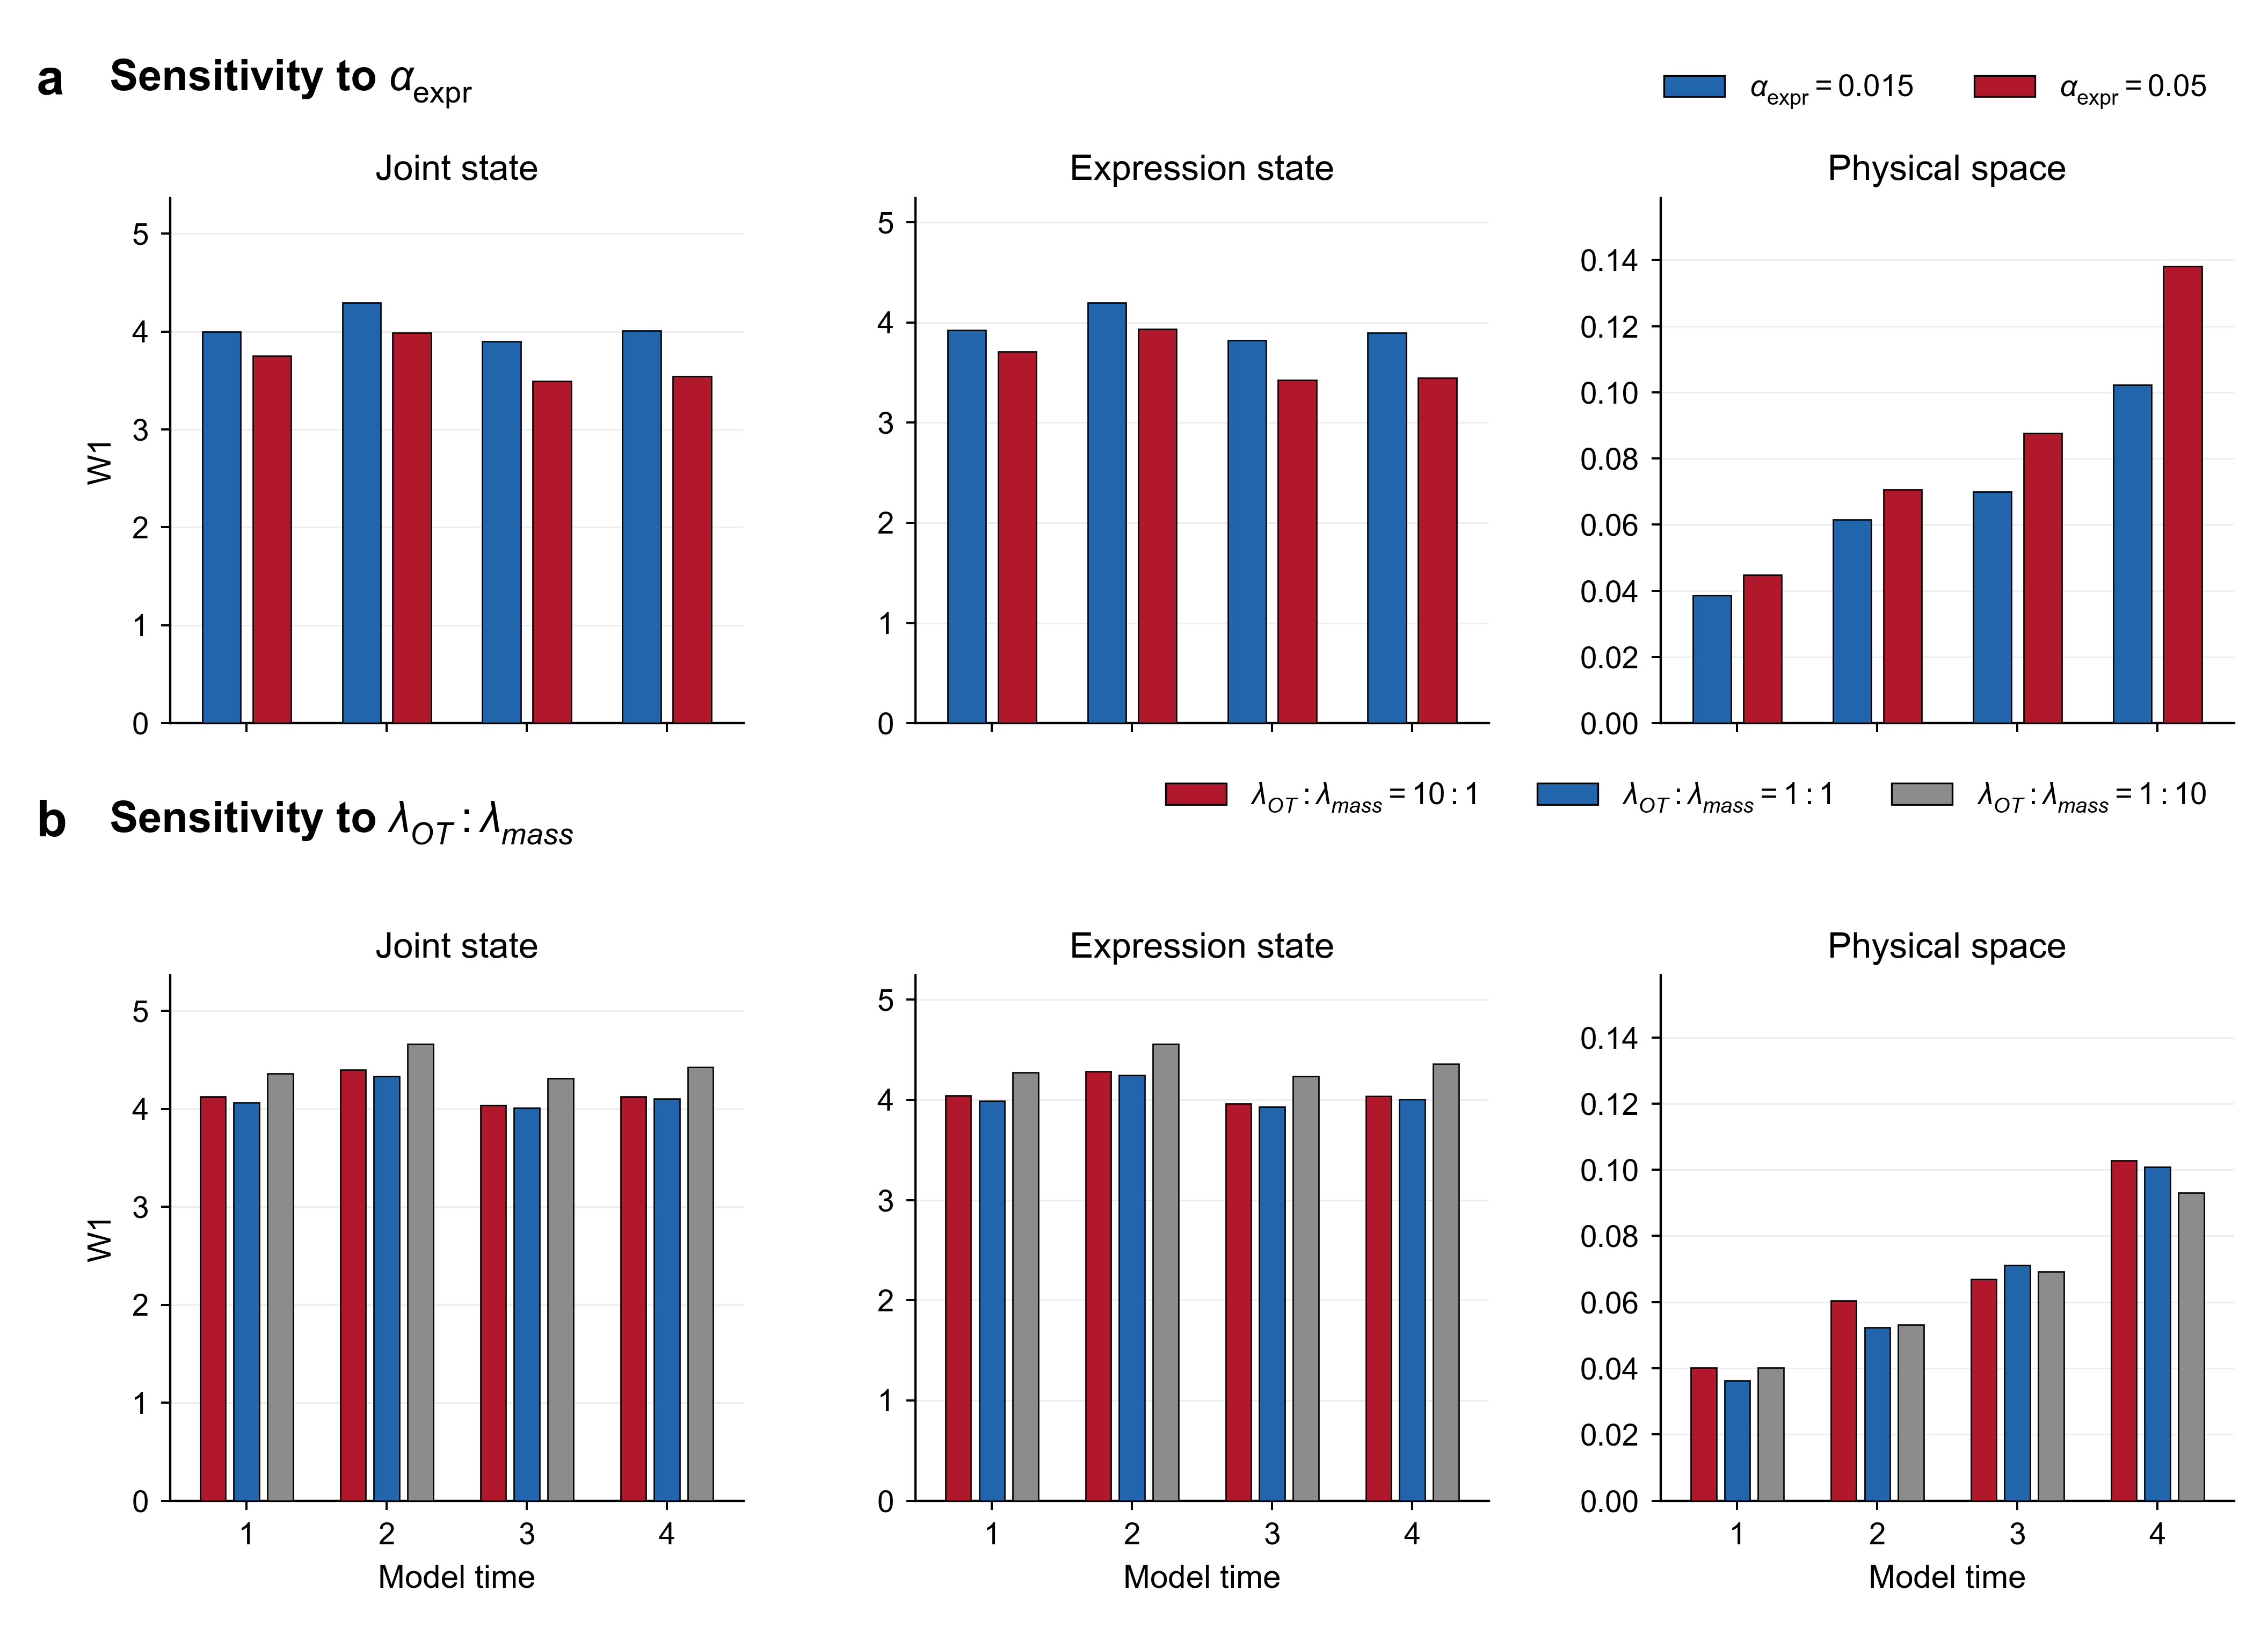

S37


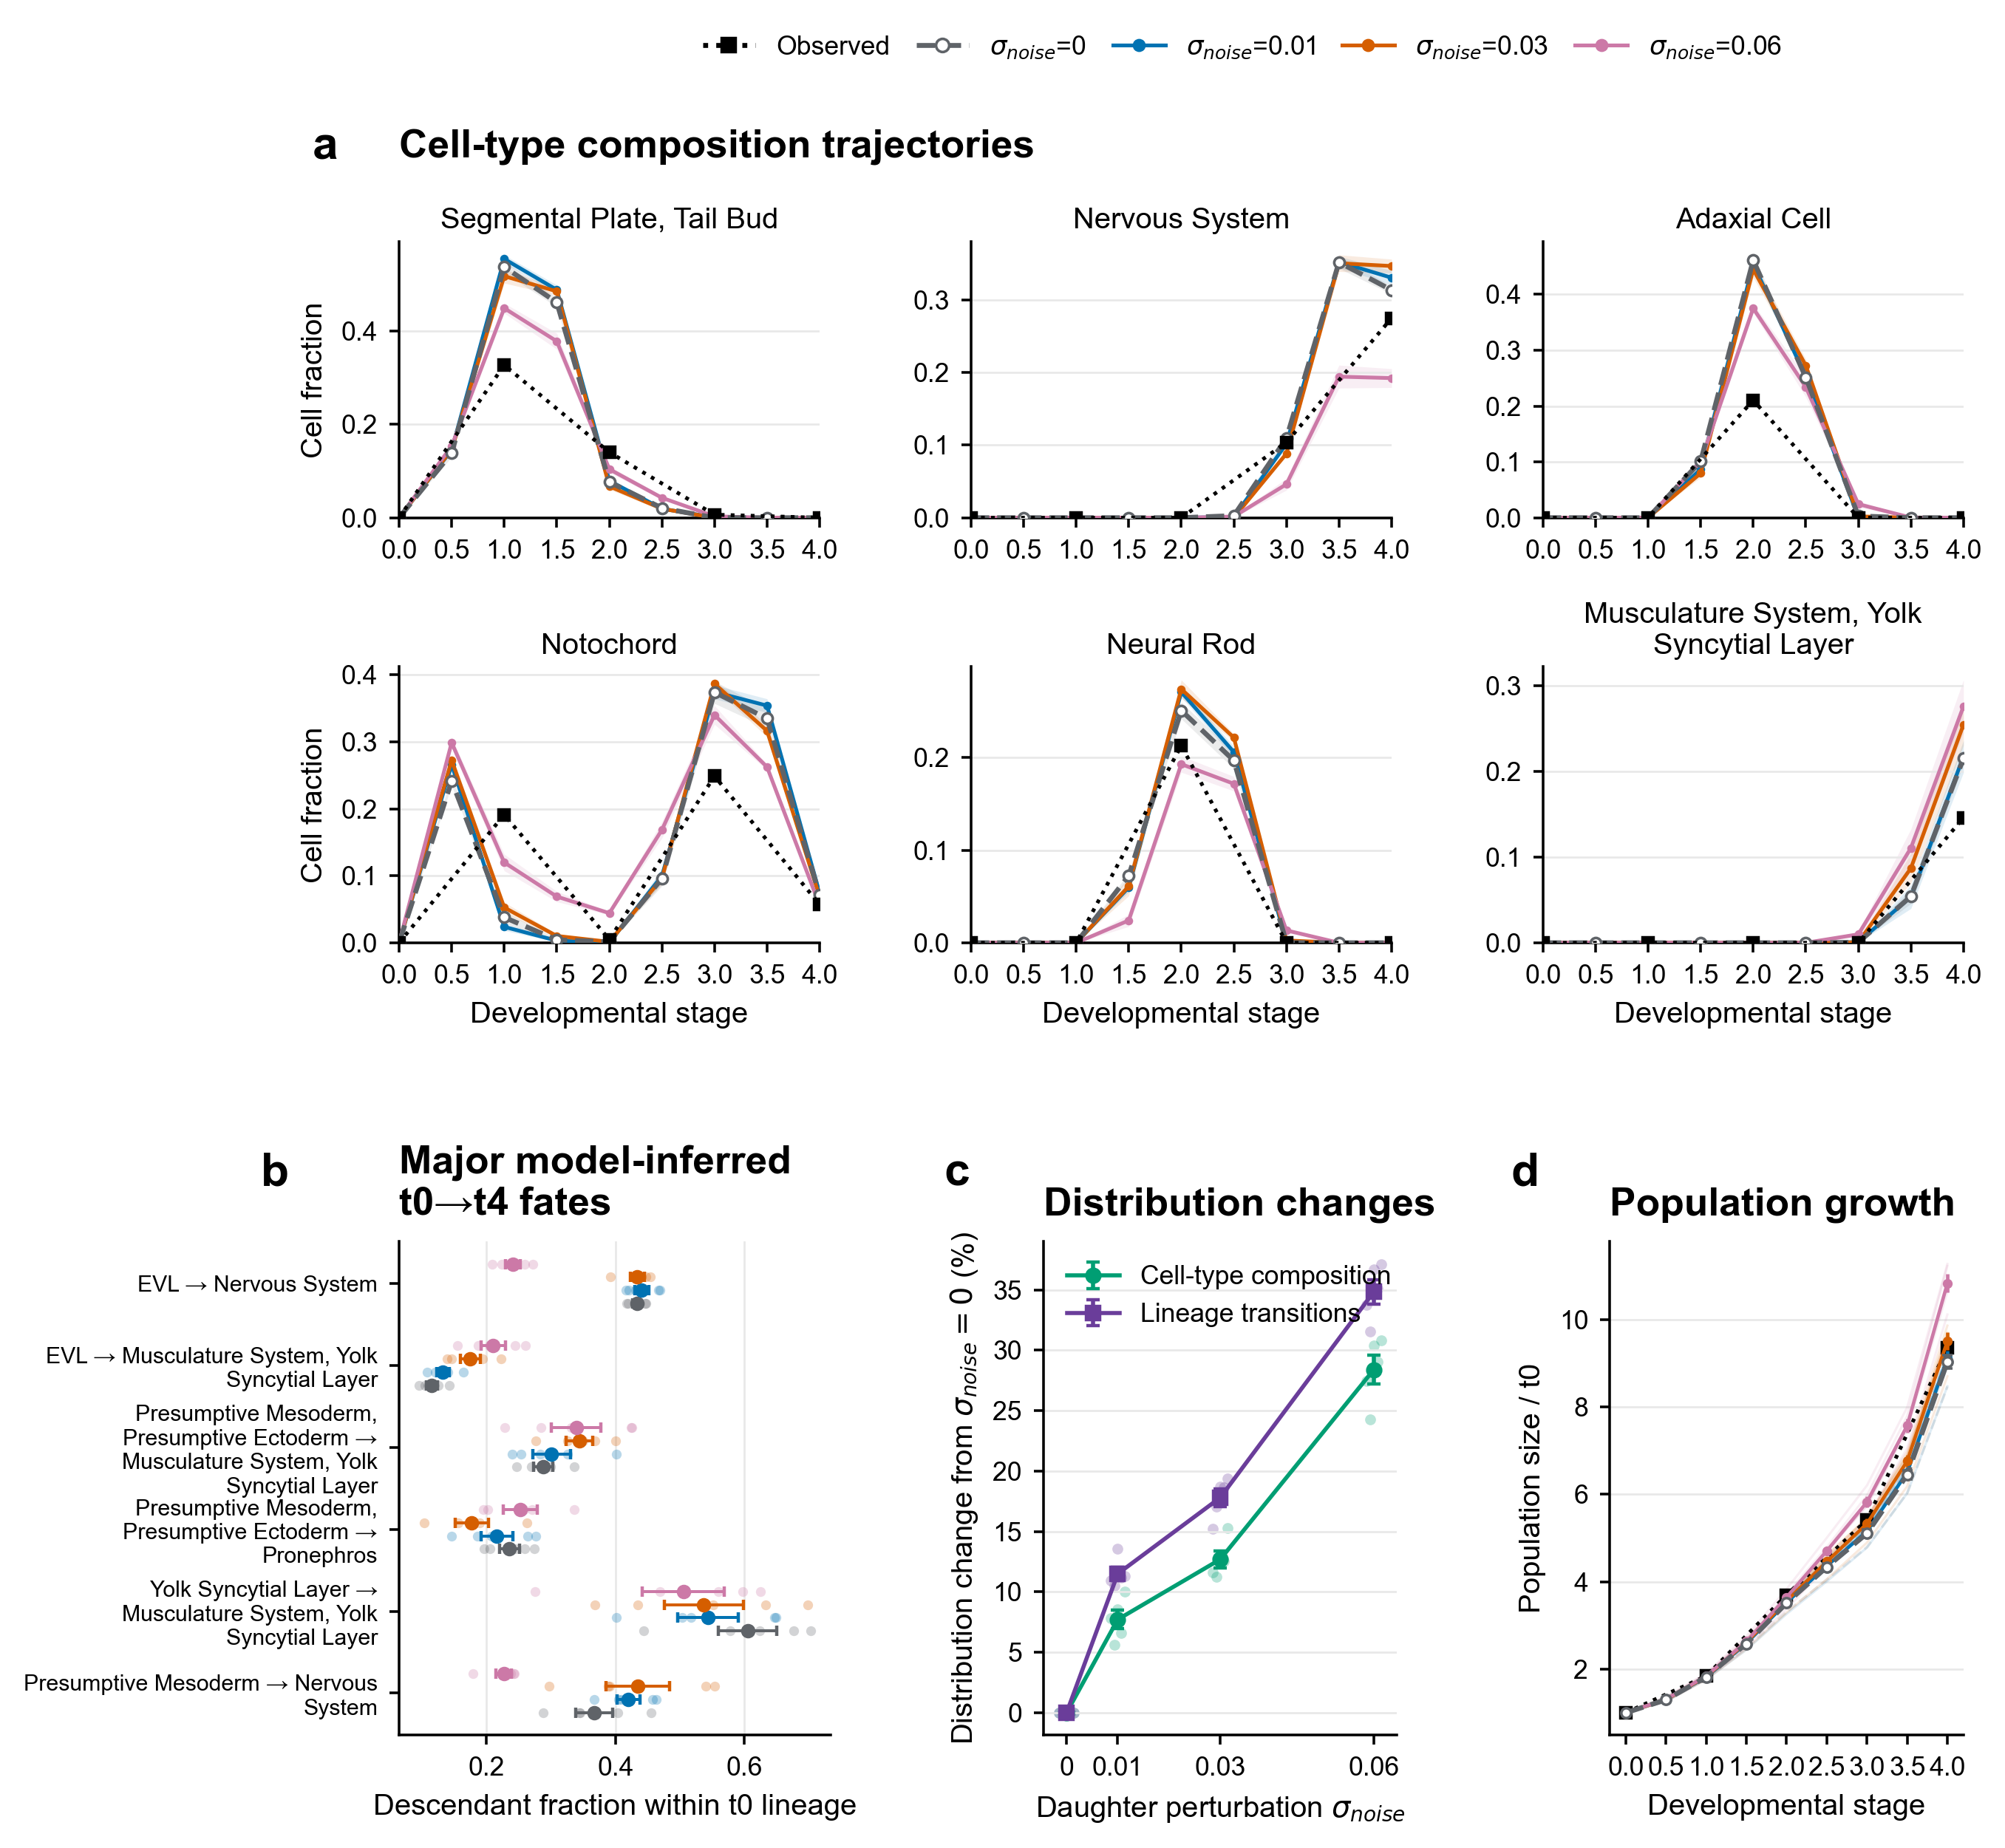

S38


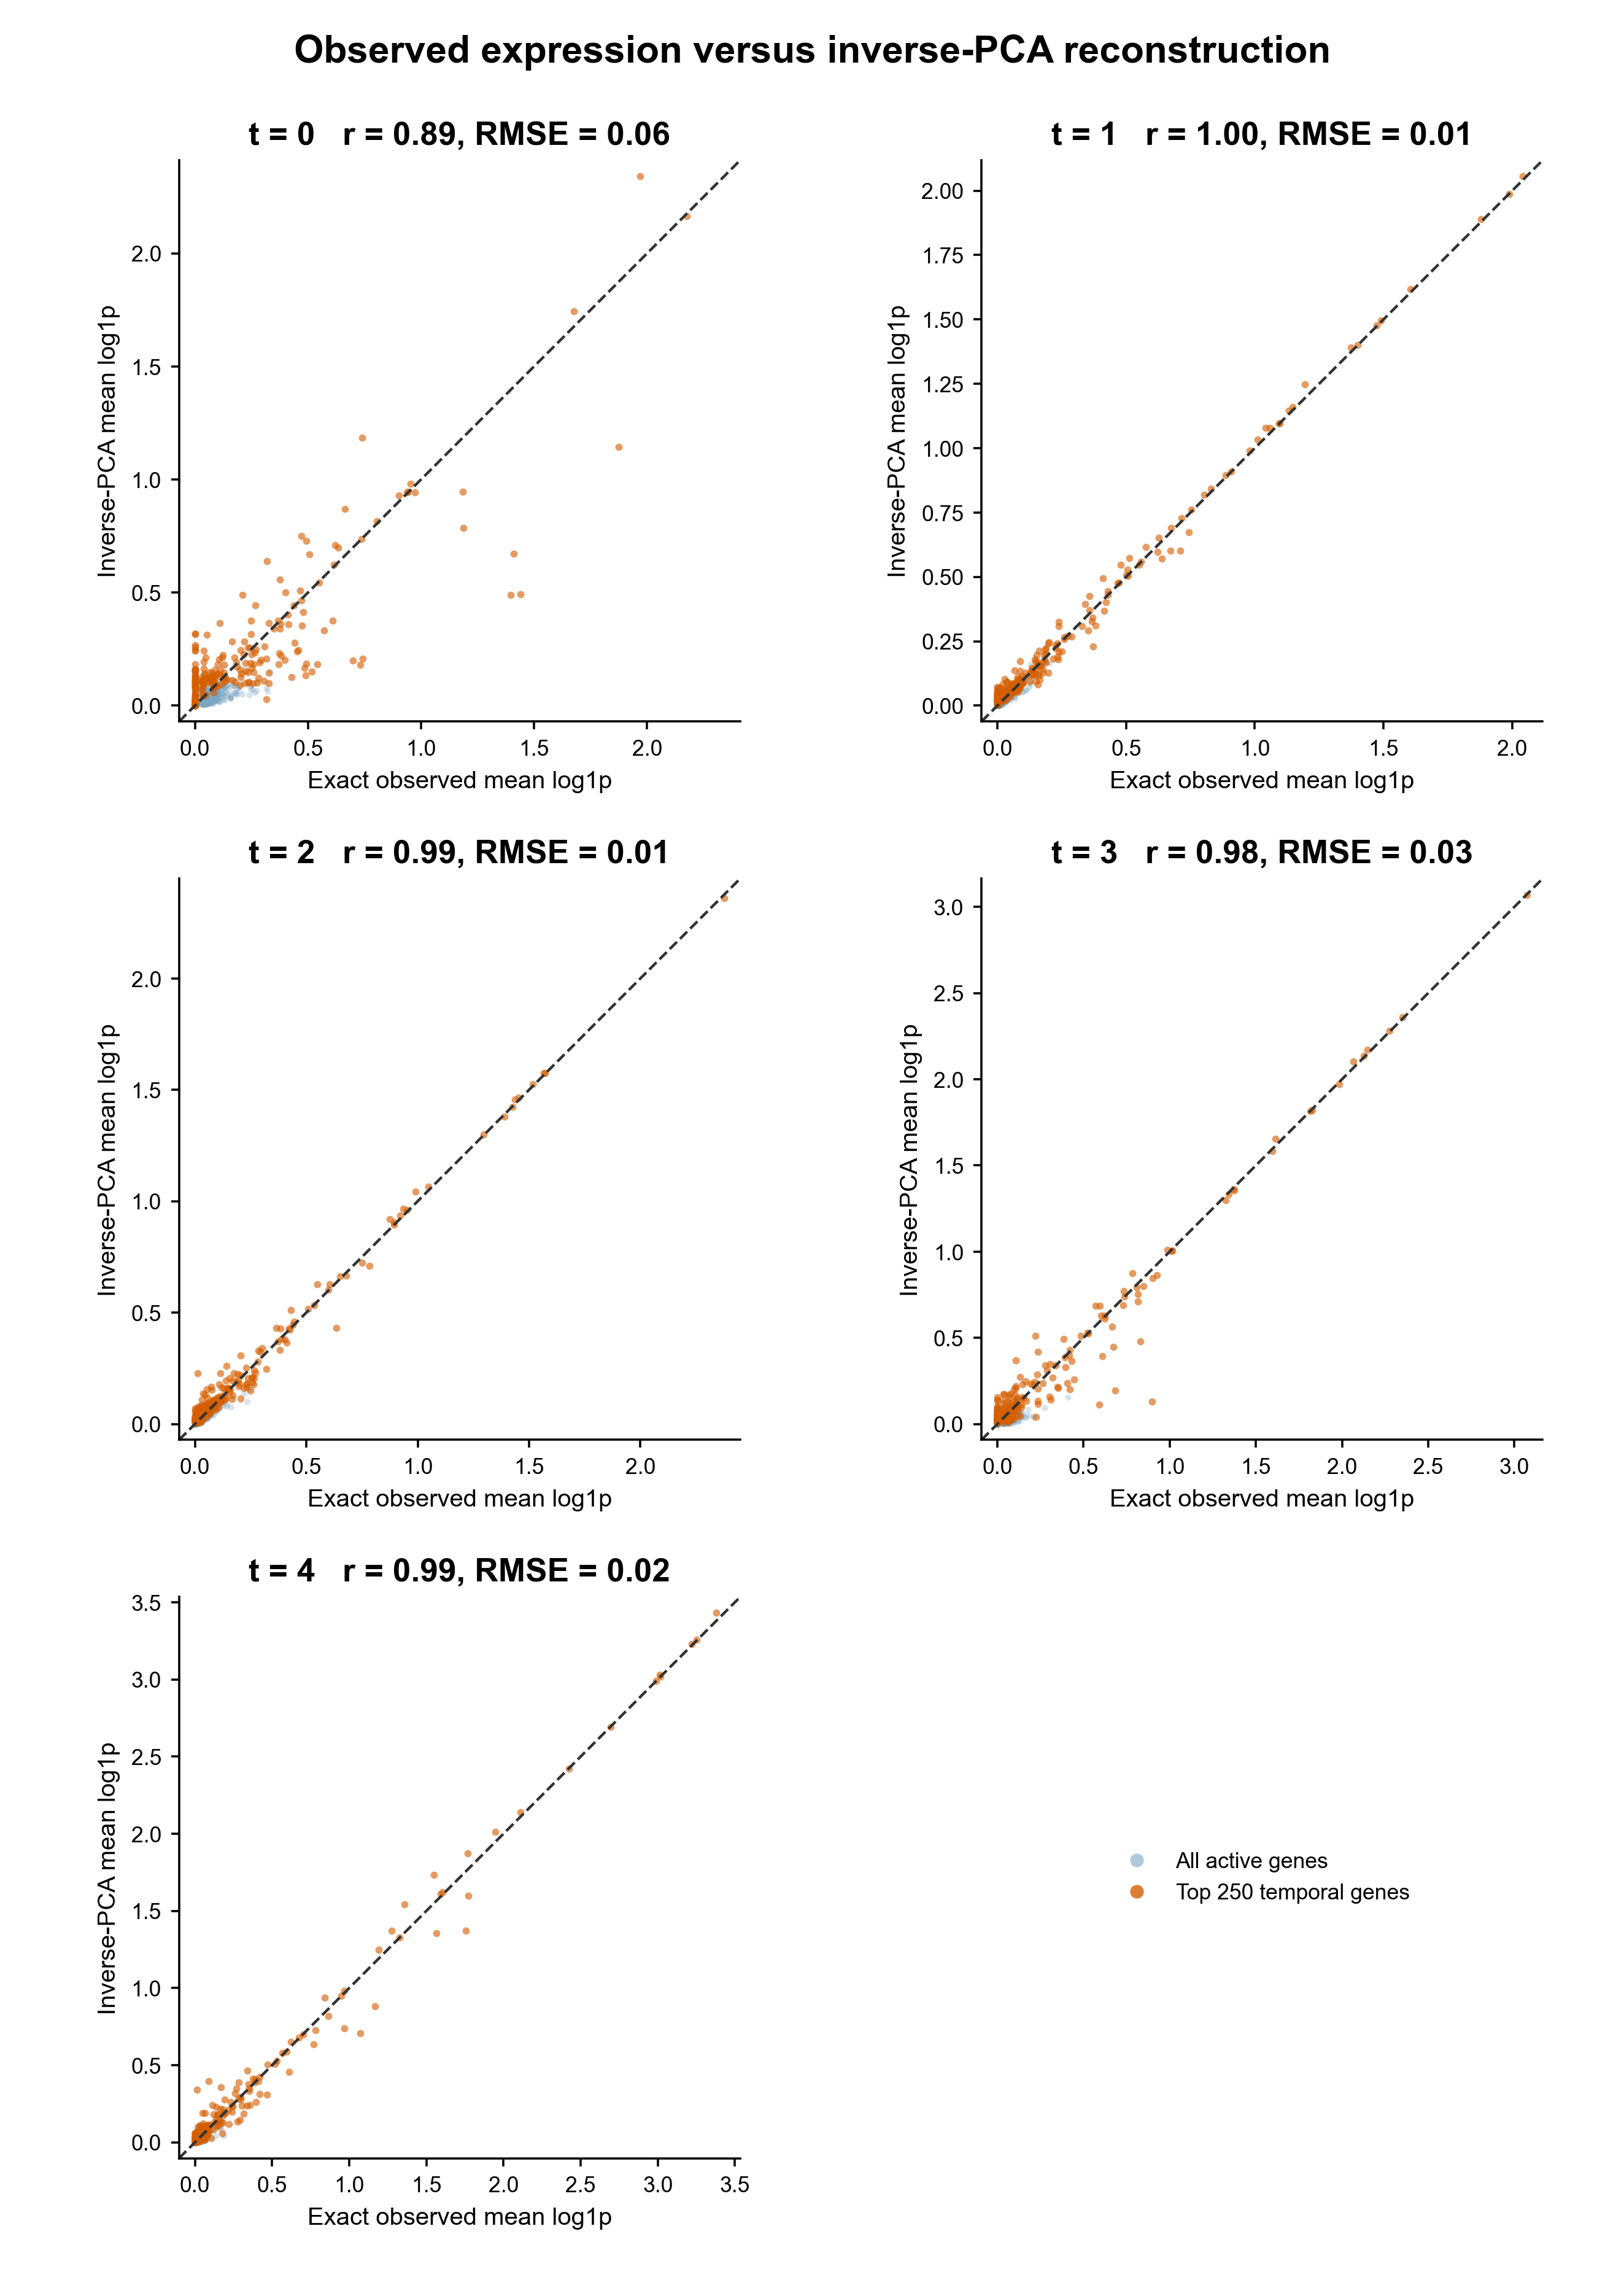

In [4]:
for figure_id, (_, png_path) in figures.items():
    print(figure_id.upper())
    display(Image(filename=str(png_path), width=720))